# Xception para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


DATASET_NAME = "caltech_birds2011"
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.20


random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Dataset cache:", TFDS_DATA_DIR)



2026-06-28 18:37:09.434833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 18:37:10.098577: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-28 18:37:13.346606: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.


In [2]:
TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases: {num_classes}")
print(f"Train examples: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Validation examples: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Test examples: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")


Splits: train[:80%] train[80%:] test


I0000 00:00:1782671842.108169   14743 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Clases: 200
Train examples: 4795
Validation examples: 1199
Test examples: 5794


## 3. Visualizar algunas imagenes del dataset


2026-06-26 01:41:36.939842: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-06-26 01:41:37.369654: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


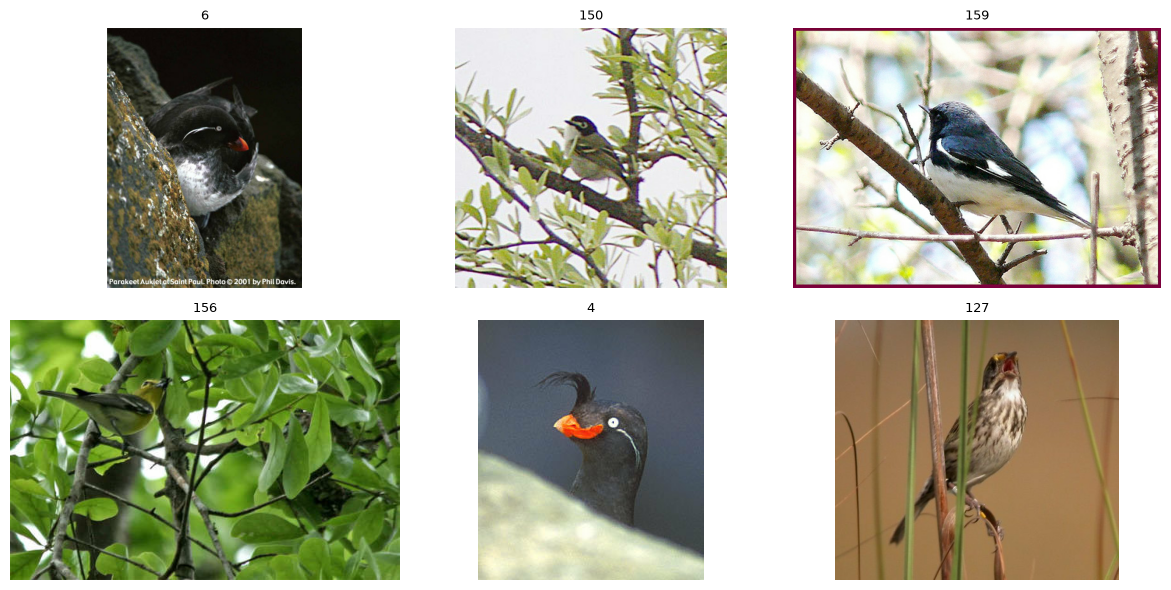

In [3]:
plt.figure(figsize=(12, 6))
for i, (image, label) in enumerate(ds_train_raw.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [3]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesamiento del Dataset
CUB tiene imagenes de tamanos variables. Usamos `resize_with_pad` para llevarlas a `299x299` sin deformar la proporcion. Luego aplicamos `preprocess_input` de Xception.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(image, label):
    """
    Redimensiona una imagen del dataset al tamaño de entrada del modelo y prepara su etiqueta.

    La imagen se ajusta con padding para conservar la proporcion original, luego se convierte
    a float32 y se aplica el preprocesamiento especifico del modelo utilizado. La etiqueta
    se castea a entero para no usar One-Hot Encoding.

    Args:
        image: Tensor con la imagen original de CUB-200-2011.
        label: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    image = tf.image.resize_with_pad(image, 299, 299)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label


def prepare_dataset(dataset, training=False):
    """
    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (image, label).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=42, reshuffle_each_iteration=True)

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch imagenes:", images.shape)
    print("Batch labels:", labels.shape)
    print("Label dtype:", labels.dtype)


2026-06-28 18:37:38.888894: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Batch imagenes: (16, 299, 299, 3)
Batch labels: (16,)
Label dtype: <dtype: 'int32'>


2026-06-28 18:37:40.717911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5.b Data augmentation

Para mejorar la generalizacion y reducir el overfitting aplicamos *data augmentation*: transformaciones aleatorias sobre las imagenes de entrenamiento. Las definimos como capas de Keras dentro del modelo, por lo que **solo se activan durante el entrenamiento** (`model.fit`) y quedan inactivas en validacion, evaluacion y prediccion.

- `RandomFlip("horizontal")`: refleja la imagen de izquierda a derecha. No usamos flip vertical porque un ave no aparece boca abajo.
- `RandomRotation(0.10)`: rota levemente la imagen (~+-10%).
- `RandomZoom(0.10)`: acerca o aleja levemente.
- `RandomContrast(0.10)`: varia el contraste.

Usamos `fill_mode="reflect"` para que las rotaciones y el zoom no dejen bordes con relleno gris.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10, fill_mode="reflect"),
        layers.RandomZoom(0.10, fill_mode="reflect"),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

In [ ]:
# Visualizamos varias versiones aumentadas de una misma imagen de entrenamiento.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), 299, 299)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 6. Definir el modelo base


Para iniciar con el transfer learning lo que hacemos es congelar todas las capas del Modelo preentrenado con el dataset de Imagenet, no incluimos su capa clasificadora. Agregamos nuestras capas finales propias que sirven para resolver el problema de clasificación que estamos abordando

In [ ]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(299, 299, 3))
#x = data_augmentation(inputs)
#Ponemos Training = False en base_model para congelar la capas de Batch Normalization
x = base_model(inputs,training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name="Xception")
model.summary()

Model: "Xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       409,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,271,280 (81.14 MB)

 Trainable params: 409,800 (1.56 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 7. Compilar el modelo


Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`. 

Epoch 1/20


2026-06-28 18:41:01.792933: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 17165056 bytes after encountering the first element of size 17165056 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-06-28 18:41:01.845572: I external/local_xla/xla/service/service.cc:163] XLA service 0x773b6c020090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-28 18:41:01.845659: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-28 18:41:02.300298: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-28 18:41:04.490896: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 9230

299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.0305 - loss: 5.1635

2026-06-28 18:42:03.681166: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-28 18:42:07.159565: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 18:42:07.339196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 18:42:09.343698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.0306 - loss: 5.1628

...

300/300 ━━━━━━━━━━━━━━━━━━━━ 111s 266ms/step - accuracy: 0.0605 - loss: 4.9678 - val_accuracy: 0.1384 - val_loss: 4.6269
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.2663 - loss: 4.2686 - val_accuracy: 0.2644 - val_loss: 4.1140
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.4015 - loss: 3.7697 - val_accuracy: 0.3261 - val_loss: 3.7202
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 140ms/step - accuracy: 0.4959 - loss: 3.3739 - val_accuracy: 0.3745 - val_loss: 3.4180
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5413 - loss: 3.1310

2026-06-28 18:45:34.232658: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


300/300 ━━━━━━━━━━━━━━━━━━━━ 45s 146ms/step - accuracy: 0.5414 - loss: 3.0670 - val_accuracy: 0.4195 - val_loss: 3.1778
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.5906 - loss: 2.8150 - val_accuracy: 0.4412 - val_loss: 2.9867
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 136ms/step - accuracy: 0.6213 - loss: 2.6052 - val_accuracy: 0.4646 - val_loss: 2.8258
Epoch 8/20
  1/300 ━━━━━━━━━━━━━━━━━━━━ 6:37 1s/step - accuracy: 0.8125 - loss: 2.4194

2026-06-28 18:47:08.537676: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 17165056 bytes after encountering the first element of size 17165056 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - accuracy: 0.6423 - loss: 2.4347 - val_accuracy: 0.4771 - val_loss: 2.6917
Epoch 9/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 140ms/step - accuracy: 0.6632 - loss: 2.2813 - val_accuracy: 0.4962 - val_loss: 2.5765
Epoch 10/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - accuracy: 0.6770 - loss: 2.1479 - val_accuracy: 0.5079 - val_loss: 2.4777
Epoch 11/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.7001 - loss: 2.0307 - val_accuracy: 0.5179 - val_loss: 2.3913
Epoch 12/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.7078 - loss: 1.9317 - val_accuracy: 0.5229 - val_loss: 2.3145
Epoch 13/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 144ms/step - accuracy: 0.7216 - loss: 1.8440 - val_accuracy: 0.5313 - val_loss: 2.2485
Epoch 14/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.7324 - loss: 1.7556 - val_accuracy: 0.5363 - val_loss: 2.1885
Epoch 15/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 138ms/step - accuracy: 0.7462 - loss: 1.6826

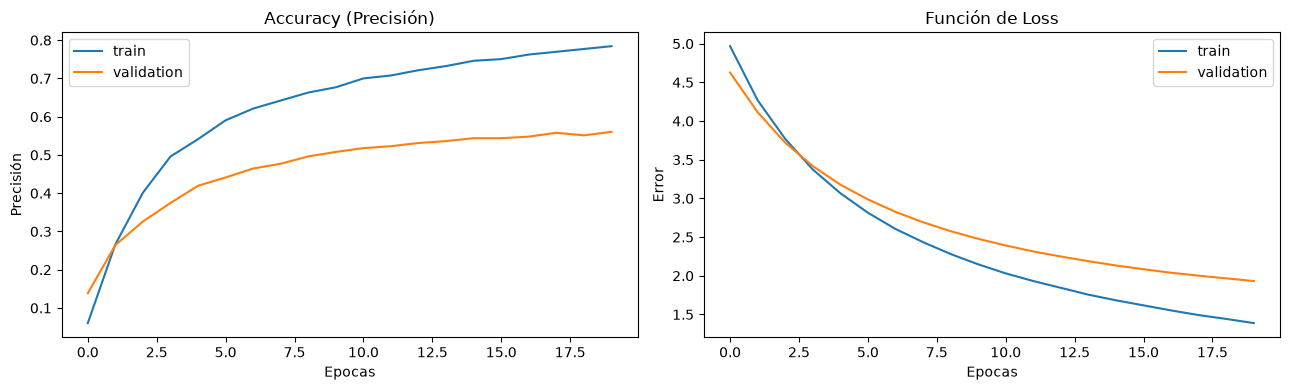

,accuracy,loss,val_accuracy,val_loss
0,0.060480,4.967753,0.138449,4.626936
1,0.266319,4.268590,0.264387,4.113971
2,0.401460,3.769665,0.326105,3.720160
3,0.495933,3.373931,0.374479,3.418004
4,0.541397,3.067001,0.419516,3.177787
5,0.590615,2.814994,0.441201,2.986689
6,0.621272,2.605182,0.464554,2.825832
7,0.642336,2.434745,0.477064,2.691687
8,0.663191,2.281274,0.496247,2.576528
9,0.676955,2.147920,0.507923,2.477726


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)

## 8. Evaluacion directa en conjunto de prueba


In [1]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


NameError: name 'model' is not defined

## 9. Aplicación de Fine-Tunning
Fine tunning consiste en que envés de congelar todo el modelo preentrenado y entrenar solo la capa final, descongelamos algunas (o todas) las capas del modelo y continuamos entrenándolas con nuestros datos, normalmente con una tasa de aprendizaje pequeña.

In [9]:
print("Numero de capas en el modelo base:", len(base_model.layers))

Numero de capas en el modelo base: 132


In [ ]:
#Partimos de la base del modelo de las celdas 6 y 7
#Descongelamos el modelo base para poder hacer fine-tunning de las ultimas capas convolucionales
base_model.trainable = True

#Elegimos la cantidad de capas a congelar para fine-tunning
fine_tunning_layers = 80

#Congelamos las primeras N capas del modelo base, dejando el resto entrenable
for layer in base_model.layers[:fine_tunning_layers]:
    layer.trainable = False

#Volvemos a compilar el modelo con un learning rate menor para no desestabilizar el entrenamiento
model.compile(
    optimizer=Adam(learning_rate= 1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 10. Matriz de confusion y reporte de clasificacion


In [ ]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 11. Guardar resultados y modelo


In [ ]:
results = {
    "modelo": "Xception",
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": 299,
    "batch_size": BATCH_SIZE,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history.history["loss"]),
    "learning_rate": LEARNING_RATE,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / "xception_results.csv"
model_path = MODELS_DIR / "xception.keras"

results_df.to_csv(results_path, index=False)
model.save(model_path)

print("Resultados guardados en:", results_path)
print("Modelo guardado en:", model_path)